# Continuous wave analysis in ATLAS

In this notebook we analyze the NANOGrav 15-year data set under a joint background and continuous wave model. We define our model to match that of [QuickCW](https://github.com/nanograv/quickcw) so we may compare our results with those previously obtained. It is straightforward to modify ATLAS' modeling choices in this notebook, if desired.

In [1]:
import sys, json, glob
sys.path.append('../')

from enterprise.pulsar import FeatherPulsar

import numpy as np
import jax
import jax.numpy as jnp
import jax.random as jr
import corner
import h5py

from numpyro.infer import MCMC, NUTS

from ATLAS.data import PTA_Data
from ATLAS.nMatrix.base import WhiteCov
from ATLAS.model import model_maker
from ATLAS.psd_functions import powerlaw, zero_orf
from ATLAS.signals.factorized.base import Red, SuperSignal
from ATLAS.signals.correlated.base import Correlated
from ATLAS.signals.deterministic.base import Deterministic
from ATLAS.signals.deterministic.det_signals import cw_delay_evolve_float64

%load_ext autoreload
%autoreload 2

JAX 64-bit mode automatically enabled successfully.


In [2]:
# check that JAX is utilizing GPUs, should see 'CudaDevice(id=...)'
print(jax.devices())

[CudaDevice(id=0), CudaDevice(id=1)]


## Load Data

Load Enterprise feather pulsars and the 15-year white noise dictionary.

In [3]:
feather_files = sorted(glob.glob('../datasets/NG15/feathers/*.feather'))
psrs = [FeatherPulsar.read_feather(f) for f in feather_files]

with open('../datasets/NG15/v1p1_wn_dict.json', 'r') as fp:
    noise_dict = json.load(fp)

FeatherPulsar.read_feather: cannot find fitpars in feather file ../datasets/NG15/feathers/v1p1_de440_pint_bipm2019-B1855+09.feather.
FeatherPulsar.read_feather: cannot find setpars in feather file ../datasets/NG15/feathers/v1p1_de440_pint_bipm2019-B1855+09.feather.
FeatherPulsar.read_feather: cannot find _pdist in feather file ../datasets/NG15/feathers/v1p1_de440_pint_bipm2019-B1855+09.feather.
FeatherPulsar.read_feather: cannot find fitpars in feather file ../datasets/NG15/feathers/v1p1_de440_pint_bipm2019-B1937+21.feather.
FeatherPulsar.read_feather: cannot find setpars in feather file ../datasets/NG15/feathers/v1p1_de440_pint_bipm2019-B1937+21.feather.
FeatherPulsar.read_feather: cannot find _pdist in feather file ../datasets/NG15/feathers/v1p1_de440_pint_bipm2019-B1937+21.feather.
FeatherPulsar.read_feather: cannot find fitpars in feather file ../datasets/NG15/feathers/v1p1_de440_pint_bipm2019-B1953+29.feather.
FeatherPulsar.read_feather: cannot find setpars in feather file ../data

## Settings

Specify the number of frequency bins and parameter bounds per signal.

In [4]:
# number of frequency bins used per signal
NFREQS_IRN = 30
NFREQS_GWB = 14
NFREQS_DET = 60

# power-law bounds [log10_A, gamma]
psd_lower, psd_upper = jnp.array([-20., 0.]), jnp.array([-8., 7.])

# CW source parameters: log10_mc, log10_fgw, cos_inc, psi, log10_h, cos_gwtheta, gwphi, phase0
cw_param_labels = [r"$\log_{10}\mathcal{M}_c$", r"$\log_{10}f_\mathrm{gw}$", r"$\cos\iota$", r"$\psi$",
                   r"$\log_{10}h$", r"$\cos\theta_\mathrm{gw}$", r"$\phi_\mathrm{gw}$", r"$\Phi_0$"]
cw_param_mins = np.array([7.2, -8.7, -1., 0, -18., -1., 0., 0.])
cw_param_maxs = np.array([9., -8.2, 1., np.pi, -12., 1., 2. * np.pi, 2. * np.pi])
cw_parameter_bounds = np.array([cw_param_mins, cw_param_maxs]).T
NPARAMS_CW = len(cw_param_labels)

In [5]:
# ATLAS data object
data = PTA_Data(psrs = psrs,
                num_gwb_bins = NFREQS_GWB,
                num_irn_bins = NFREQS_IRN,
                num_det_bins = NFREQS_DET,
                num_dm_bins = None,
                fixed_white_noise_params = None,
                linear_timing = True,
                marg_timing = True,
                diag_white_cov = False,
                fixed_res = False,
                noise_dict = noise_dict)

# get vector of white noise parameters
wn = WhiteCov(data = data, stabilize_TNT = True)
wn_vec = wn.params_dict_to_vector(noise_dict)

Constructing the white noise cov matrix for J2322+2057: 100%|██████████| 67/67 [00:18<00:00,  3.53it/s]


## Model

 - We fix the white noise and analytically marginalize over linear deviations to the timing model.

 - The background and intrinsic pulsar noise use power law spectral models.
 
 - In order to match the modeling choices of [QuickCW](https://github.com/nanograv/quickcw), we assume the background does not induce inter-pulsar correlations (i.e. a CURN background), although ATLAS can efficiently model a Hellings-Downs background + CW.

 - We use the evolving Earth/pulsar term CW model presented in Ellis et. al 2012, 2013.

In [6]:
# define constituent signal / noise models
sig_unc = Red(name = 'unc', data = data, psd_function = powerlaw, nfreqs = NFREQS_IRN,
              lower_bound_psd = psd_lower, upper_bound_psd = psd_upper)
sig_cor = Correlated(name = 'cor', data = data, psd_function = powerlaw, orf_function = zero_orf,
                     nfreqs = NFREQS_GWB, lower_bound_psd = psd_lower, upper_bound_psd = psd_upper)
sig_cw  = Deterministic(name = 'det', data = data, get_delays_func = cw_delay_evolve_float64,
                        det_parameter_bounds = cw_parameter_bounds, nfreqs_det = NFREQS_DET)

# combine components into joint model
super_sig = SuperSignal(signal_list = [sig_unc, sig_cor, sig_cw],
                        signal_combination_string = "ltm|unc+cor->unc ; det",
                        data = data)

# get helper objects for posterior evaluation (e.g. "TNT", "TNr", etc.)
helpers = super_sig.get_helpers(reff = jnp.concat(data.raw_residuals), white_noise_params = wn_vec)

E0917 11:38:52.085161 2452527 slow_operation_alarm.cc:73] Constant folding an instruction is taking > 1s:

  %gather.4510 = f64[88680,1,423]{2,1,0} gather(%constant.3230, %constant.11883), offset_dims={1,2}, collapsed_slice_dims={}, start_index_map={0}, index_vector_dim=1, slice_sizes={1,423}, metadata={op_name="jit(update_white_matrix_products_unjitted)/jit(_solve_marg)/gather" stack_frame_id=178}

This isn't necessarily a bug; constant-folding is inherently a trade-off between compilation time and speed at runtime. XLA has some guards that attempt to keep constant folding from taking too long, but fundamentally you'll always be able to come up with an input program that takes a long time.

If you'd like to file a bug, run with envvar XLA_FLAGS=--xla_dump_to=/tmp/foo and attach the results.
E0917 11:38:53.150273 2452097 slow_operation_alarm.cc:140] The operation took 2.065236816s
Constant folding an instruction is taking > 1s:

  %gather.4510 = f64[88680,1,423]{2,1,0} gather(%constant

## Sample

Sample the posterior with NumPyro's NUTS. `model_maker` is the NumPyro model with arguments passed through `mcmc.run`.

In [7]:
# run NUTS
nuts_kernel = NUTS(model = model_maker)
mcmc = MCMC(sampler = nuts_kernel,
            num_warmup = 500,
            num_samples = 3000)
mcmc.run(jr.key(170817),
         raw_residuals = None,
         super_sig = super_sig,
         marg_over_non_gwb = False,
         helpers = helpers)
samples = mcmc.get_samples()

sample: 100%|██████████| 3500/3500 [1:11:35<00:00,  1.23s/it, 255 steps of size 1.86e-02. acc. prob=0.89]


In [8]:
# load QuickCW samples for comparison
with h5py.File('../datasets/NG15/15yr_quickCW_detection.h5', 'r') as f:
    par_names = [n.decode() for n in f['par_names'][:]]
    quickCW_samples = f['samples_cold'][0, :, :]  # cold chain, shape (N, n_par)

# re-order quickCW samples to match our convention
cw_par_order = ['log10_mc', 'log10_fgw', 'cos_inc', 'psi',
                'log10_h', 'cos_gwtheta', 'gwphi', 'phase0']
cw_params = np.array([quickCW_samples[:, par_names.index('0_' + p)] for p in cw_par_order]).T
mask = np.all((cw_params >= cw_parameter_bounds[:, 0]) & 
            (cw_params <= cw_parameter_bounds[:, 1]), axis=1)
quickCW_samples = cw_params[mask]

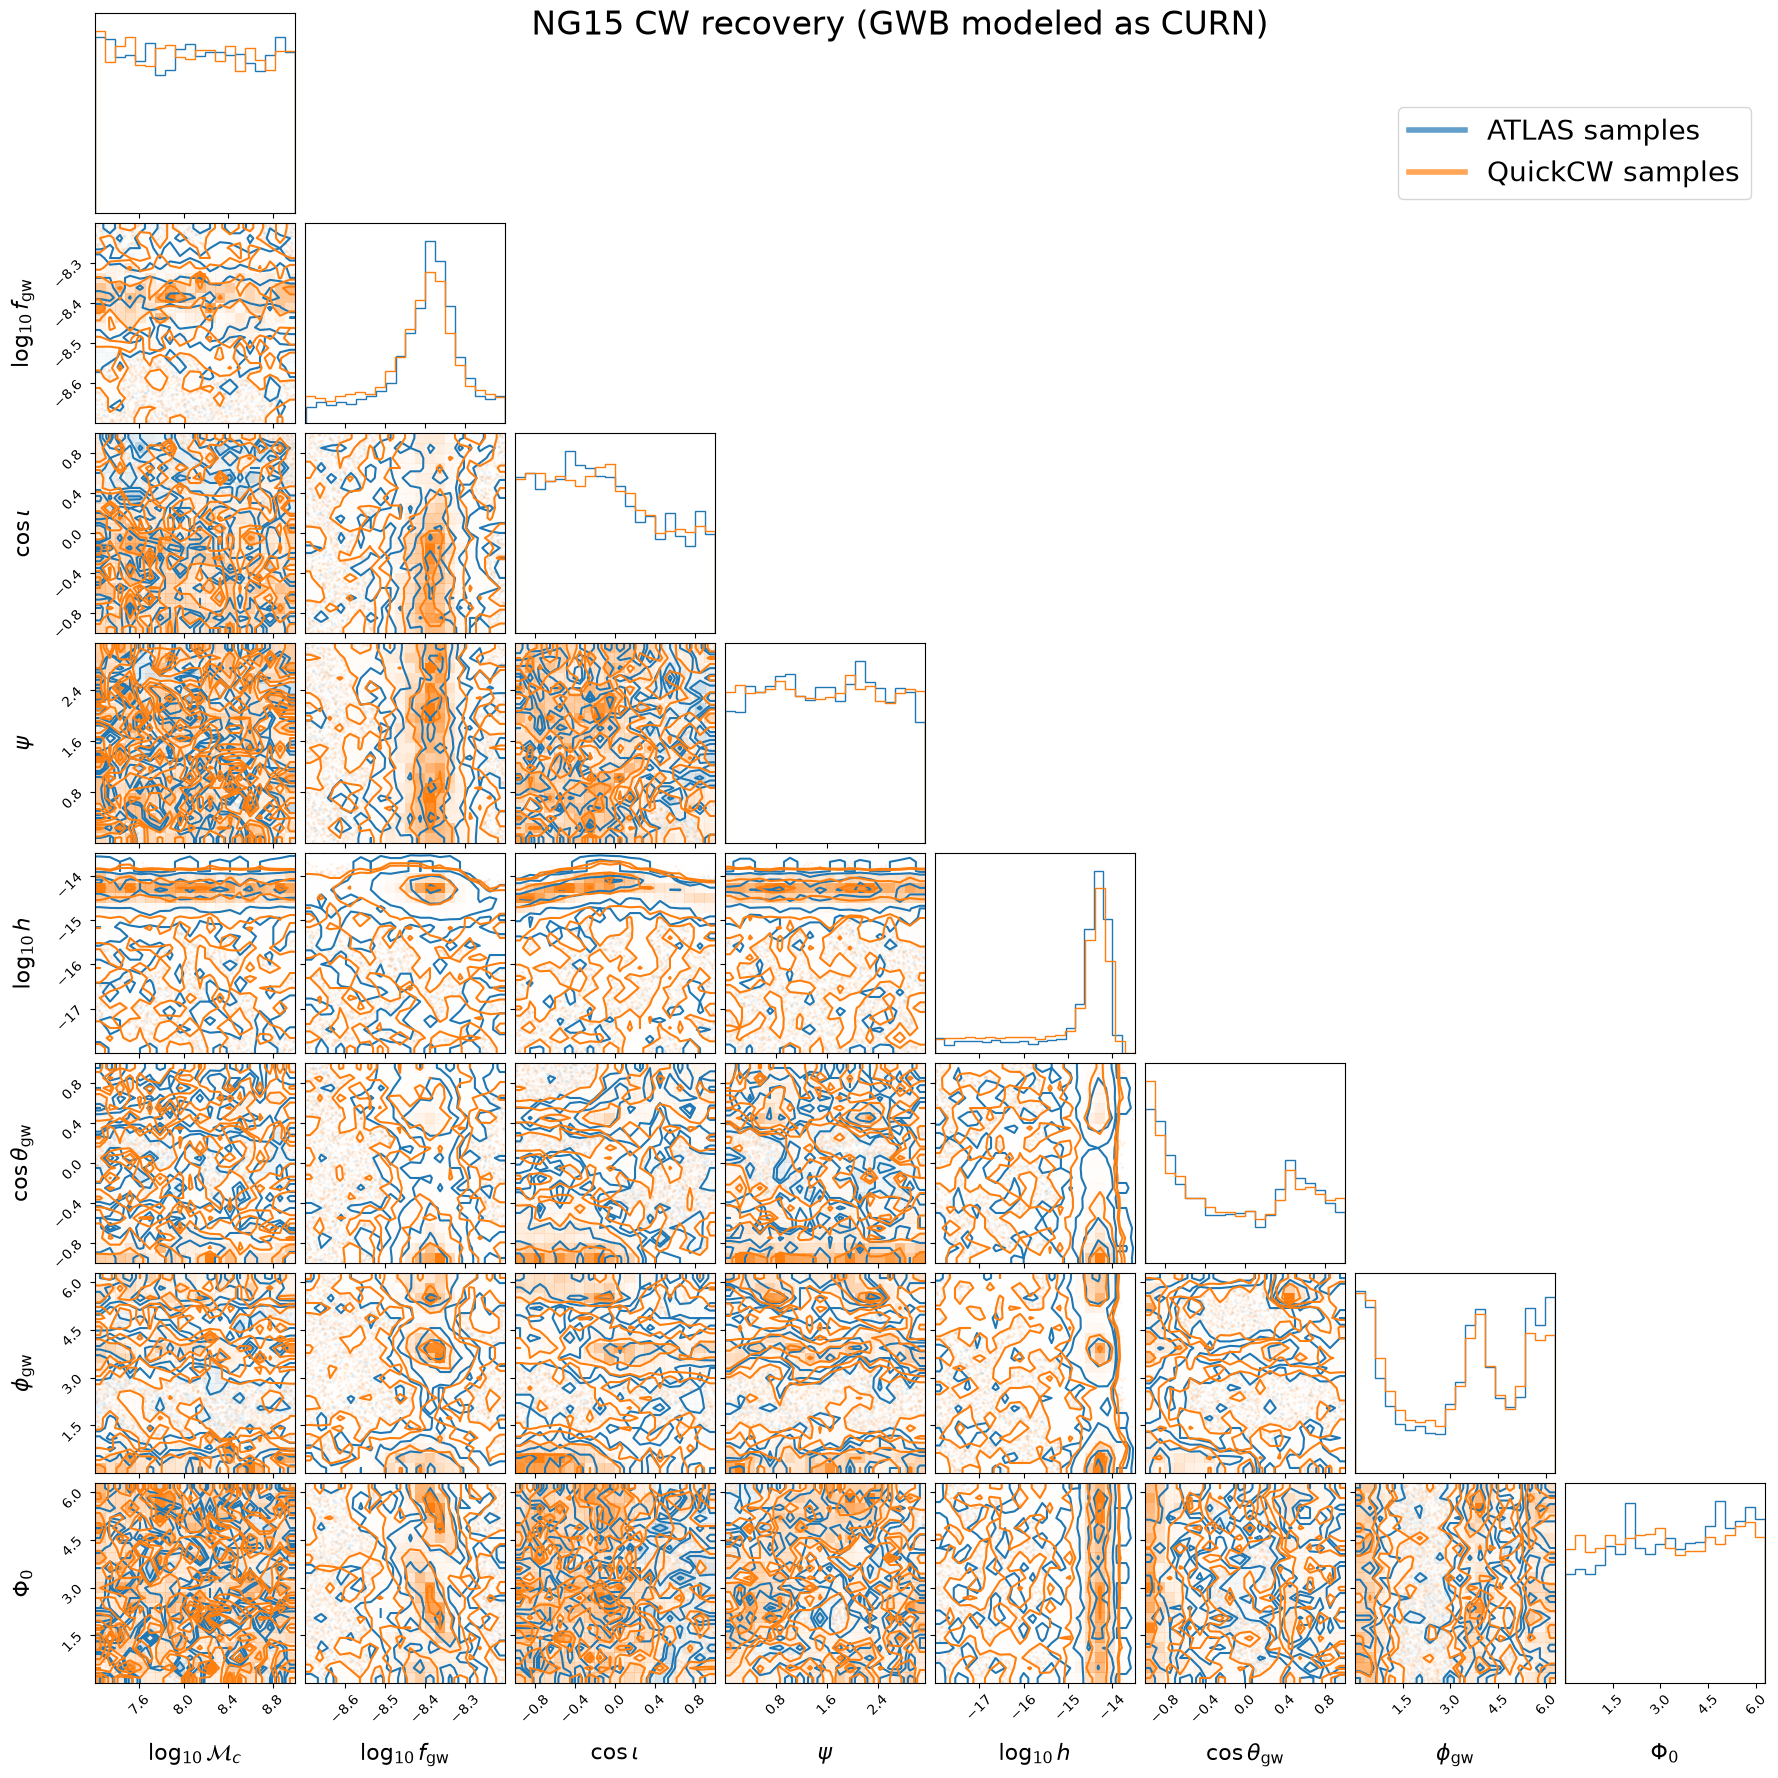

In [9]:
# plot CW recovery under CURN GWB model

# plot samples from Prometheus
fig = corner.corner(data = np.array(samples['det_params']),
                    labels = cw_param_labels,
                    label_kwargs = {'fontsize': 16},
                    color = 'C0',
                    hist_kwargs = {'density': True})

# plot samples from QuickCW
corner.corner(data = quickCW_samples,
              fig = fig,
              color = 'C1',
              hist_kwargs = {'density': True})

# plot legend/title
axes = np.array(fig.axes).reshape((NPARAMS_CW, NPARAMS_CW))
axes[0, -1].plot([], [], color='C0', label='ATLAS samples', alpha=0.7, lw=4)
axes[0, -1].plot([], [], color='C1', label='QuickCW samples', alpha=0.7, lw=4)
axes[0, -1].legend(fontsize=20, loc='lower right')
fig.suptitle('NG15 CW recovery (GWB modeled as CURN)',
             fontsize=24)
fig.show()